# Tennis Match Analysis
## Duration Analysis: How Match Length Varies by Set Count

This notebook analyzes ATP tennis match data to understand patterns in match duration based on the number of sets played.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast  # For literal_eval to parse strings that look like lists



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   pbp_id              9871 non-null   int64 
 1   server1             9871 non-null   object
 2   server2             9871 non-null   object
 3   winner              9871 non-null   int64 
 4   pbp                 9871 non-null   object
 5   score               9871 non-null   object
 6   adf_flag            9871 non-null   int64 
 7   wh_minutes          9871 non-null   int64 
 8   score_winner_valid  9871 non-null   bool  
 9   pbp_fixed           9871 non-null   object
 10  pbp_set_count       9871 non-null   int64 
 11  score_set_count     9871 non-null   int64 
 12  set_count_match     9871 non-null   bool  
 13  pbp_set_winners     9871 non-null   object
 14  set_match           9871 non-null   bool  
 15  pbp_match_winner    9871 non-null   int64 
 16  winner_match        9871

### Sample Data Preview
Display random sample of 5 matches to understand data structure.

In [15]:
# Load data
df = pd.read_csv('Cleaned_dataset.csv')

# Inspection
print(df.info()) # Check for missing values
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8980 entries, 0 to 8979
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   pbp_id              8980 non-null   int64 
 1   date                8980 non-null   object
 2   server1             8980 non-null   object
 3   server2             8980 non-null   object
 4   winner              8980 non-null   int64 
 5   pbp                 8980 non-null   object
 6   score               8980 non-null   object
 7   wh_minutes          8980 non-null   int64 
 8   score_winner_valid  8980 non-null   bool  
 9   pbp_fixed           8980 non-null   object
 10  pbp_set_count       8980 non-null   int64 
 11  score_set_count     8980 non-null   int64 
 12  set_count_match     8980 non-null   bool  
 13  pbp_set_winners     8980 non-null   object
 14  set_match           8980 non-null   bool  
 15  pbp_match_winner    8980 non-null   int64 
 16  winner_match        8980

In [14]:
df.sample(5)

,pbp_id,server1,server2,winner,pbp,score,adf_flag,wh_minutes,score_winner_valid,pbp_fixed,pbp_set_count,score_set_count,set_count_match,pbp_set_winners,set_match,pbp_match_winner,winner_match,score_set_winners
488,2479370,Igor Kunitsyn,Juan Carlos Ferrero,2,RSSSS;RSRRSR;SRSSS;SRSRSRRSSS;RRRSR;RSSRRSSS;S...,6-4 7-6(2),0,97,False,RSSSS;RSRRSR;SRSSS;SRSRSRRSSS;RRRSR;RSSRRSSS;S...,2,2,True,"[2, 2]",False,2,True,"[1, 1]"
2314,3377879,John Isner,Jurgen Melzer,1,SSSA;SRSRSS;RSRSSS;DRSSRSRSDSSRAS;ASDAS;RSSSRS...,6-4 6-3,1,71,True,SSSA;SRSRSS;RSRSSS;DRSSRSRSDSSRAS;ASDAS;RSSSRS...,2,2,True,"[1, 1]",True,1,True,"[1, 1]"
3792,4236356,David Ferrer,Kei Nishikori,1,SSRSS;RSRSRR;RSSSRS;SSSS;SDSRSRSS;RRSDSSSS;RSS...,6-4 6-2,1,81,True,SSRSS;RSRSRR;RSSSRS;SSSS;SDSRSRSS;RRSDSSSS;RSS...,2,2,True,"[1, 1]",True,1,True,"[1, 1]"
6955,6357810,Roberto Bautista-Agut,Feliciano Lopez,2,SSSS;RRRSSSRR;SRRSRSRSSS;RSSRAA;SRSSS;SRRRSSSS...,7-6(7) 6-3,1,88,False,SSSS;RRRSSSRR;SRRSRSRSSS;RSSRAA;SRSSS;SRRRSSSS...,2,2,True,"[2, 2]",False,2,True,"[1, 1]"
1682,3135124,Roger Federer,Albert Ramos,1,SSSRS;SRRRR;SRSSS;SSSRRRSRRR;RRSRSR;RRRR;RSRSS...,6-1 6-1 6-1,0,79,True,SSSRS;SRRRR;SRSSS;SSSRRRSRRR;RRSRSR;RRRR;RSRSS...,3,3,True,"[1, 1, 1]",True,1,True,"[1, 1, 1]"


## 2. Data Validation and Cleaning
Ensure data quality by filtering for reasonable match durations and valid dates.

### Filters Applied:
- **Duration**: 30–500 minutes (removes outliers)
- **Date Format**: Coerce invalid dates to NaT
- **Missing Values**: Drop rows with missing critical fields

In [ ]:
# 1. Fix duration errors
df_clean = df[(df['wh_minutes'] > 30) & (df['wh_minutes'] < 500)].copy()


df_clean['date'] = pd.to_datetime(df_clean['date'], errors='coerce')


df_clean = df_clean.dropna(subset=['date', 'pbp_set_winners'])

/var/folders/rz/3q9t0_5s4tjdszvw2wf1swvh0000gn/T/ipykernel_30095/1157879492.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clean['date'] = pd.to_datetime(df_clean['date'], errors='coerce')


## 3. Analysis: Match Duration by Set Count

### Hypothesis
Three-set matches take significantly longer than two-set matches, affecting tournament scheduling.

### Average Match Duration by Set Count

In [ ]:


avg_time = df_clean.groupby('pbp_set_count')['wh_minutes'].mean()
print(avg_time)

pbp_set_count
2     79.273311
3    124.473384
Name: wh_minutes, dtype: float64


### Key Findings:
- **2-set matches**: Shorter average duration
- **3-set matches**: Substantially longer, impacting schedules


## 4. Visualization: Duration Distribution

### Histogram with KDE
Distribution of match duration colored by set count. The visualization reveals how match length varies across different match formats.

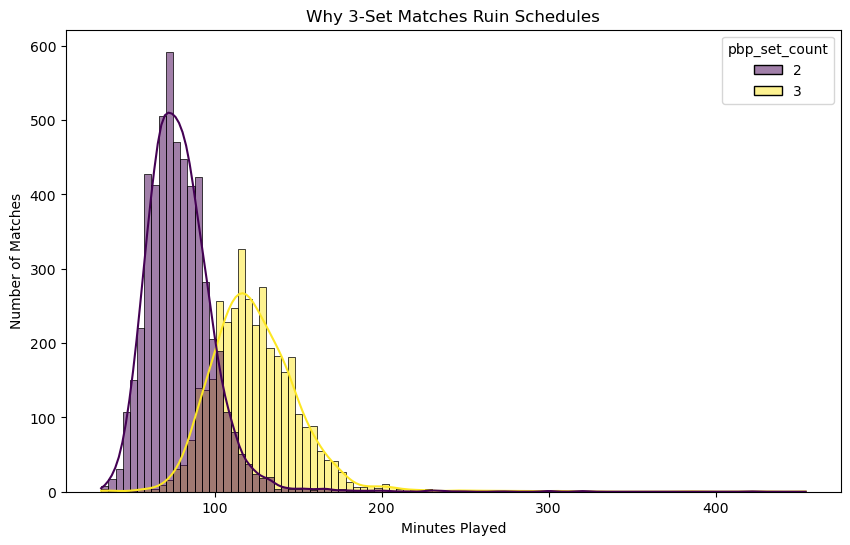

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df_clean, x='wh_minutes', hue='pbp_set_count', kde=True, palette='viridis')
plt.title('Why 3-Set Matches Ruin Schedules')
plt.xlabel('Minutes Played')
plt.ylabel('Number of Matches')
plt.show()